In [1]:
# Dataset: Harga Rumah
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

In [2]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Load data
df = pd.read_csv("jabodetabek_house_price.csv")

# Tampilkan 5 baris pertama dengan function head
print(df.head())

# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info
print(df.info())

# Menampilkan statistik deskriptif dataset dengan menjalankan describe
print(df.describe())

                                                 url   price_in_rp  \
0  https://www.rumah123.com/properti/bekasi/hos11...  2.990000e+09   
1  https://www.rumah123.com/properti/bekasi/hos10...  1.270000e+09   
2  https://www.rumah123.com/properti/bekasi/hos10...  1.950000e+09   
3  https://www.rumah123.com/properti/bekasi/hos10...  3.300000e+09   
4  https://www.rumah123.com/properti/bekasi/hos10...  4.500000e+09   

                                               title  \
0  Rumah cantik Sumarecon Bekasi\nLingkungan asri...   
1          Rumah Kekinian, Magenta Summarecon Bekasi   
2  Rumah Cantik 2 Lantai Cluster Bluebell Summare...   
3  Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...   
4  Rumah Hoek di Cluster Maple Summarecon Bekasi,...   

                     address           district     city       lat  \
0  Summarecon Bekasi, Bekasi  Summarecon Bekasi   Bekasi -6.223945   
1  Summarecon Bekasi, Bekasi  Summarecon Bekasi   Bekasi -6.223945   
2  Summarecon Bekasi, Bekasi  Su

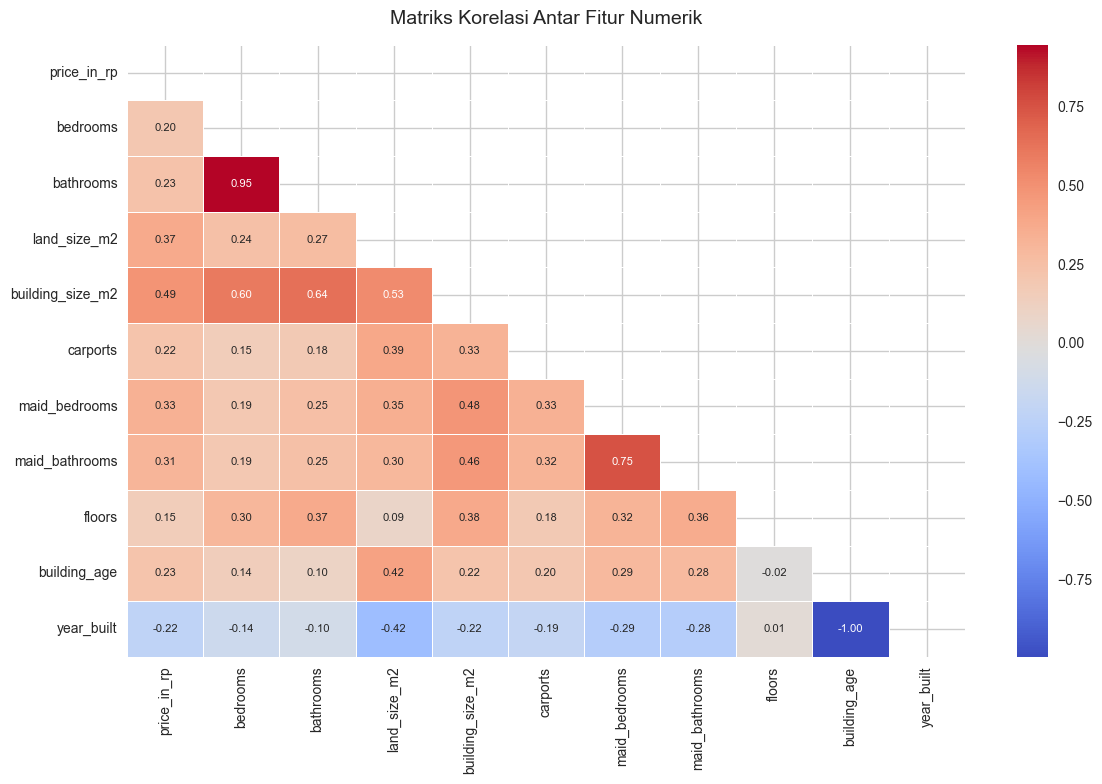

In [3]:
# Menampilkan matriks korelasi antar fitur numerik
num_cols_eda = ['price_in_rp', 'bedrooms', 'bathrooms', 'land_size_m2',
                'building_size_m2', 'carports', 'maid_bedrooms',
                'maid_bathrooms', 'floors', 'building_age', 'year_built']
 
# Filter hanya kolom yang ada di dataset
num_cols_eda = [c for c in num_cols_eda if c in df.columns]
 
corr_matrix = df[num_cols_eda].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))
 
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', ax=ax, linewidths=0.5,
            annot_kws={"size": 8})
ax.set_title('Matriks Korelasi Antar Fitur Numerik', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

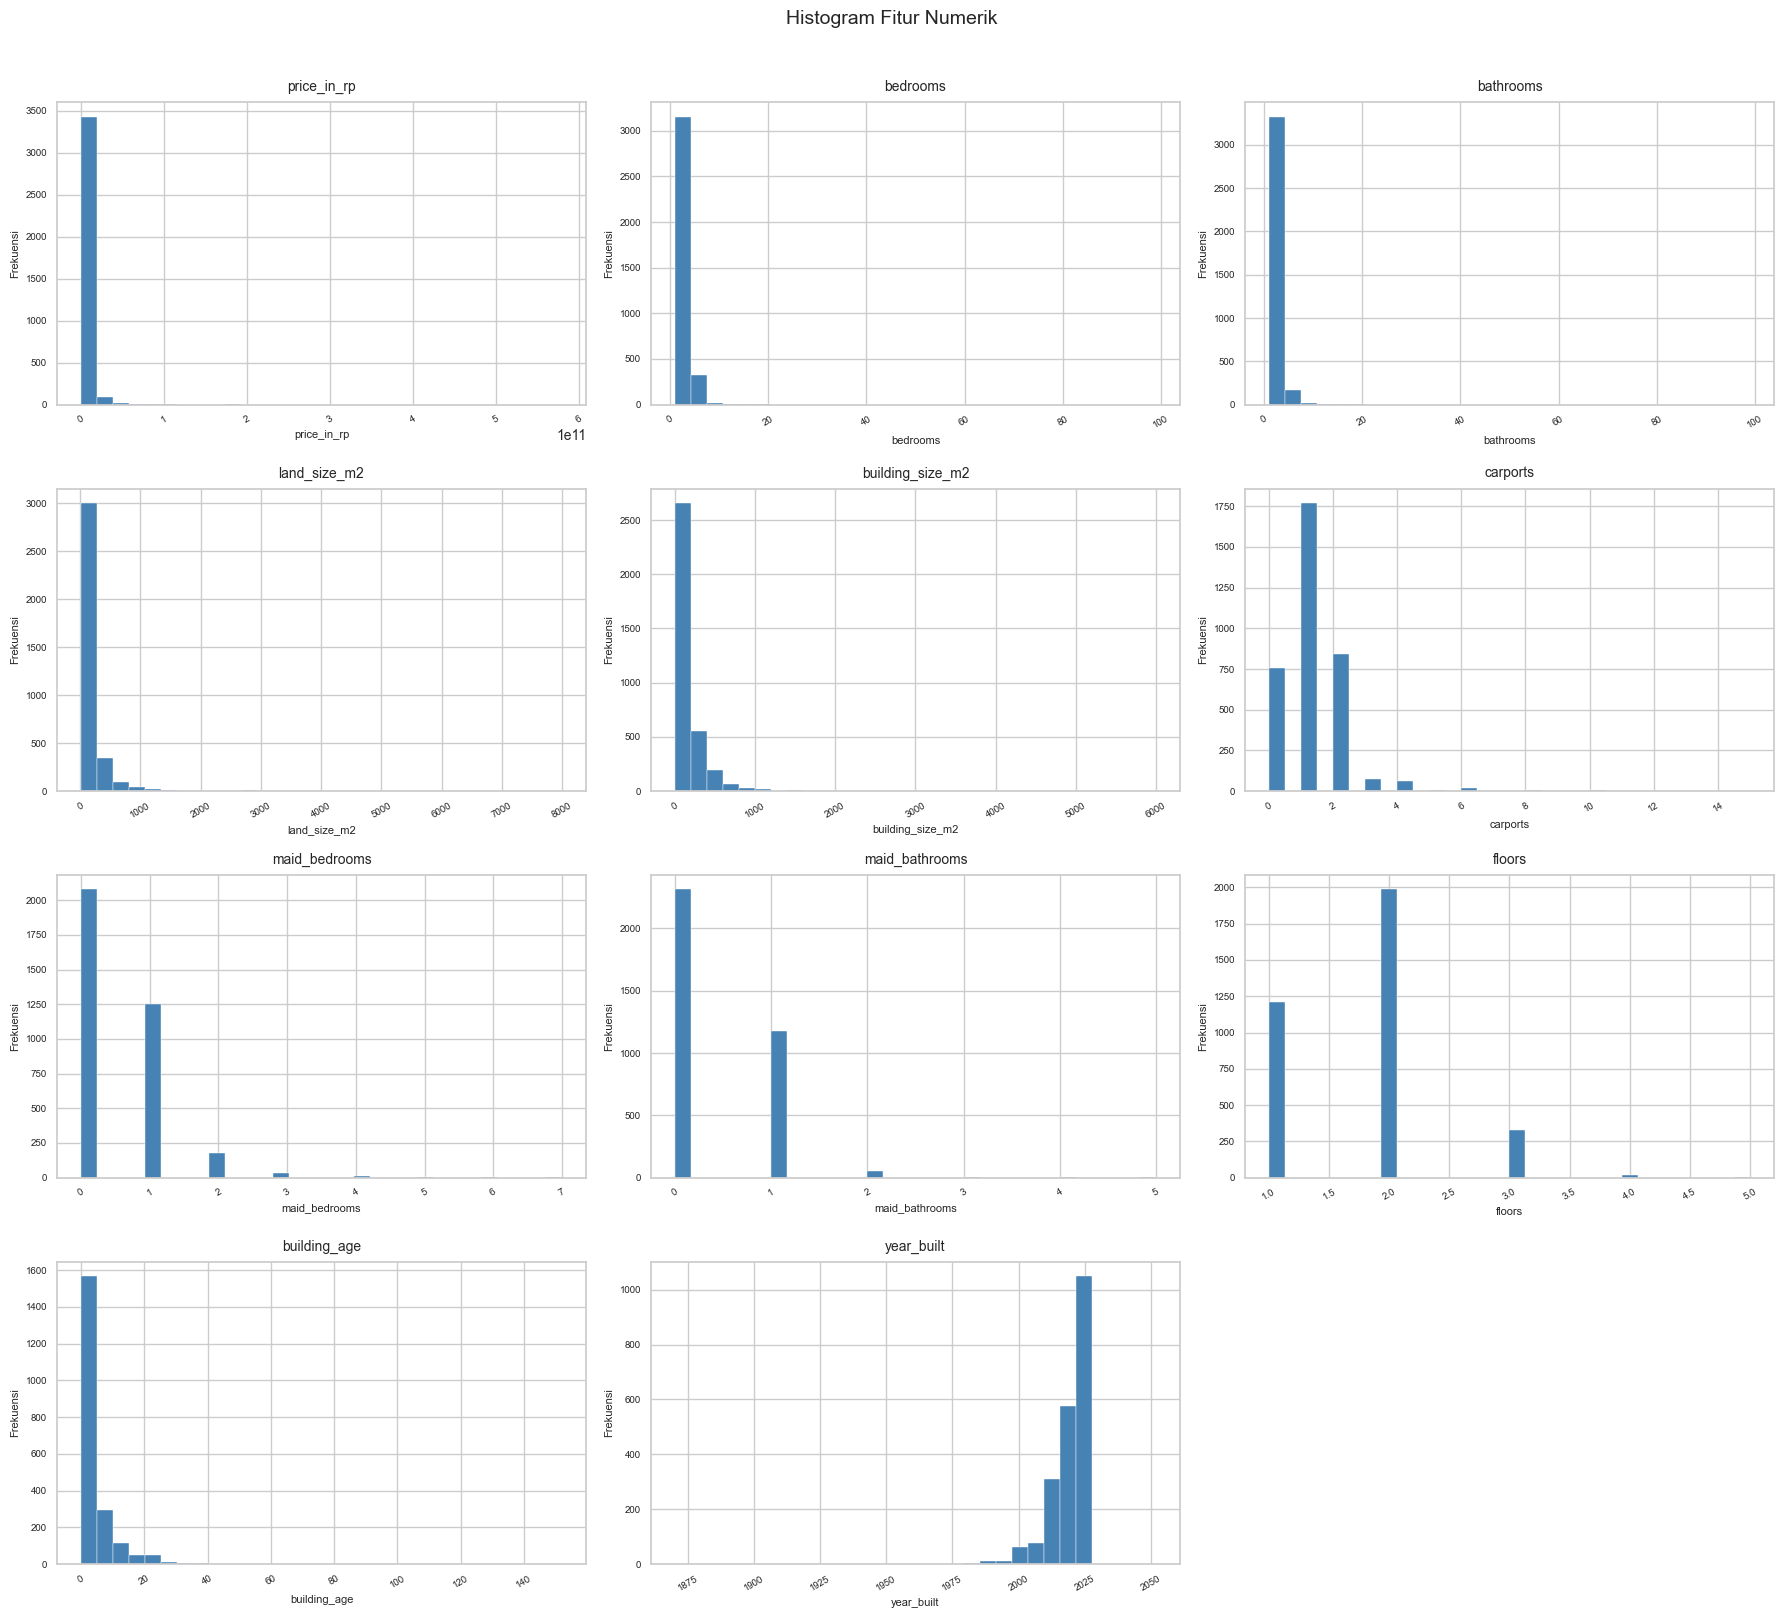

In [4]:
# Menampilkan histogram untuk semua kolom numerik
num_cols_hist = [c for c in num_cols_eda if c in df.columns]
n_cols_plot   = 3
n_rows_plot   = (len(num_cols_hist) + n_cols_plot - 1) // n_cols_plot
 
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten()
 
for i, col in enumerate(num_cols_hist):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10, pad=8)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Histogram Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_histograms_num.png', dpi=150, bbox_inches='tight')
plt.show()

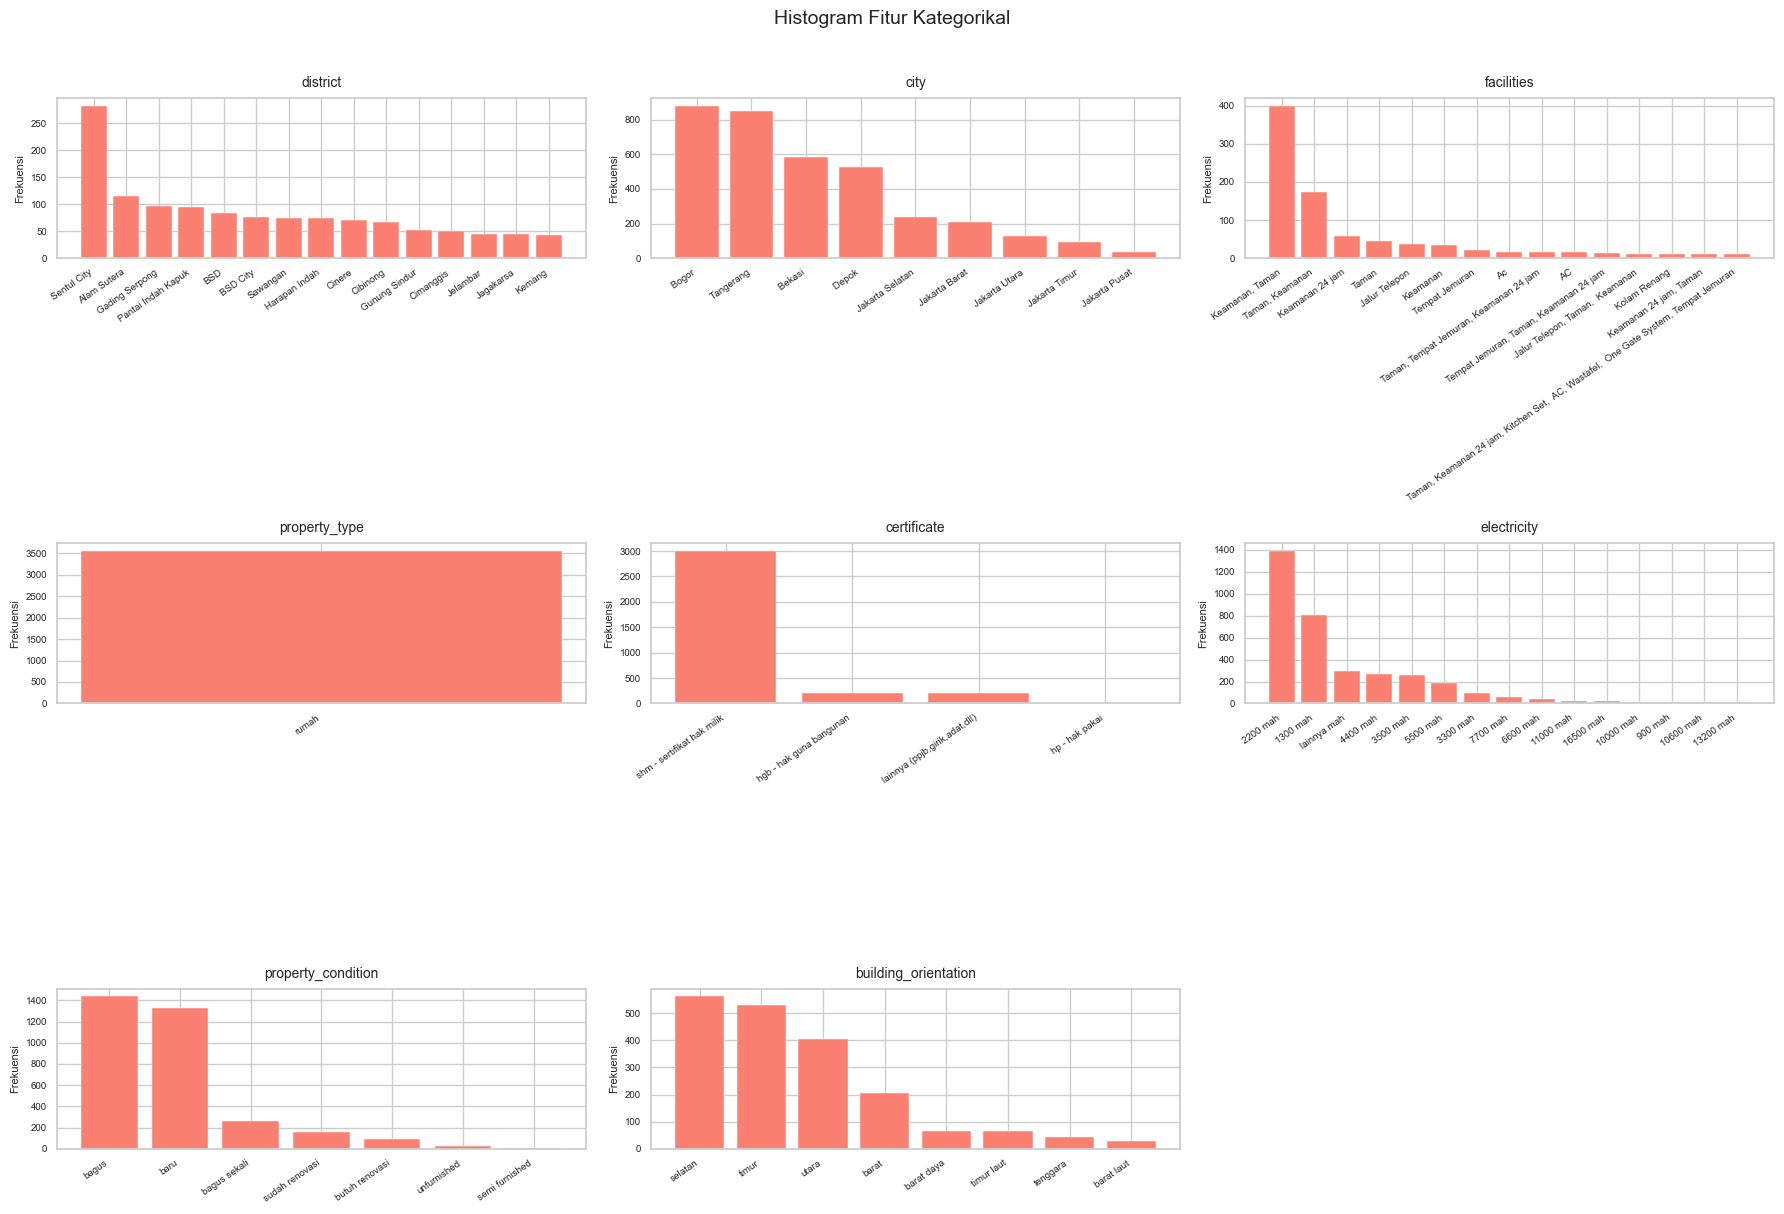

In [5]:
# Menampilkan histogram untuk semua kolom kategorikal
cat_cols_hist = ['district', 'city', 'facilities', 'property_type',
                 'certificate', 'electricity', 'property_condition',
                 'building_orientation']
cat_cols_hist = [c for c in cat_cols_hist if c in df.columns]
 
n_cols_cat  = 3
n_rows_cat  = (len(cat_cols_hist) + n_cols_cat - 1) // n_cols_cat
 
fig, axes = plt.subplots(n_rows_cat, n_cols_cat,
                         figsize=(6 * n_cols_cat, 4 * n_rows_cat))
axes = axes.flatten()
 
for i, col in enumerate(cat_cols_hist):
    val_counts = df[col].value_counts().head(15)
    axes[i].bar(range(len(val_counts)), val_counts.values,
                color='salmon', edgecolor='white')
    axes[i].set_xticks(range(len(val_counts)))
    axes[i].set_xticklabels(val_counts.index, rotation=35, ha='right', fontsize=7)
    axes[i].set_title(col, fontsize=10, pad=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Histogram Fitur Kategorikal', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_histograms_cat.png', dpi=150, bbox_inches='tight')
plt.show()

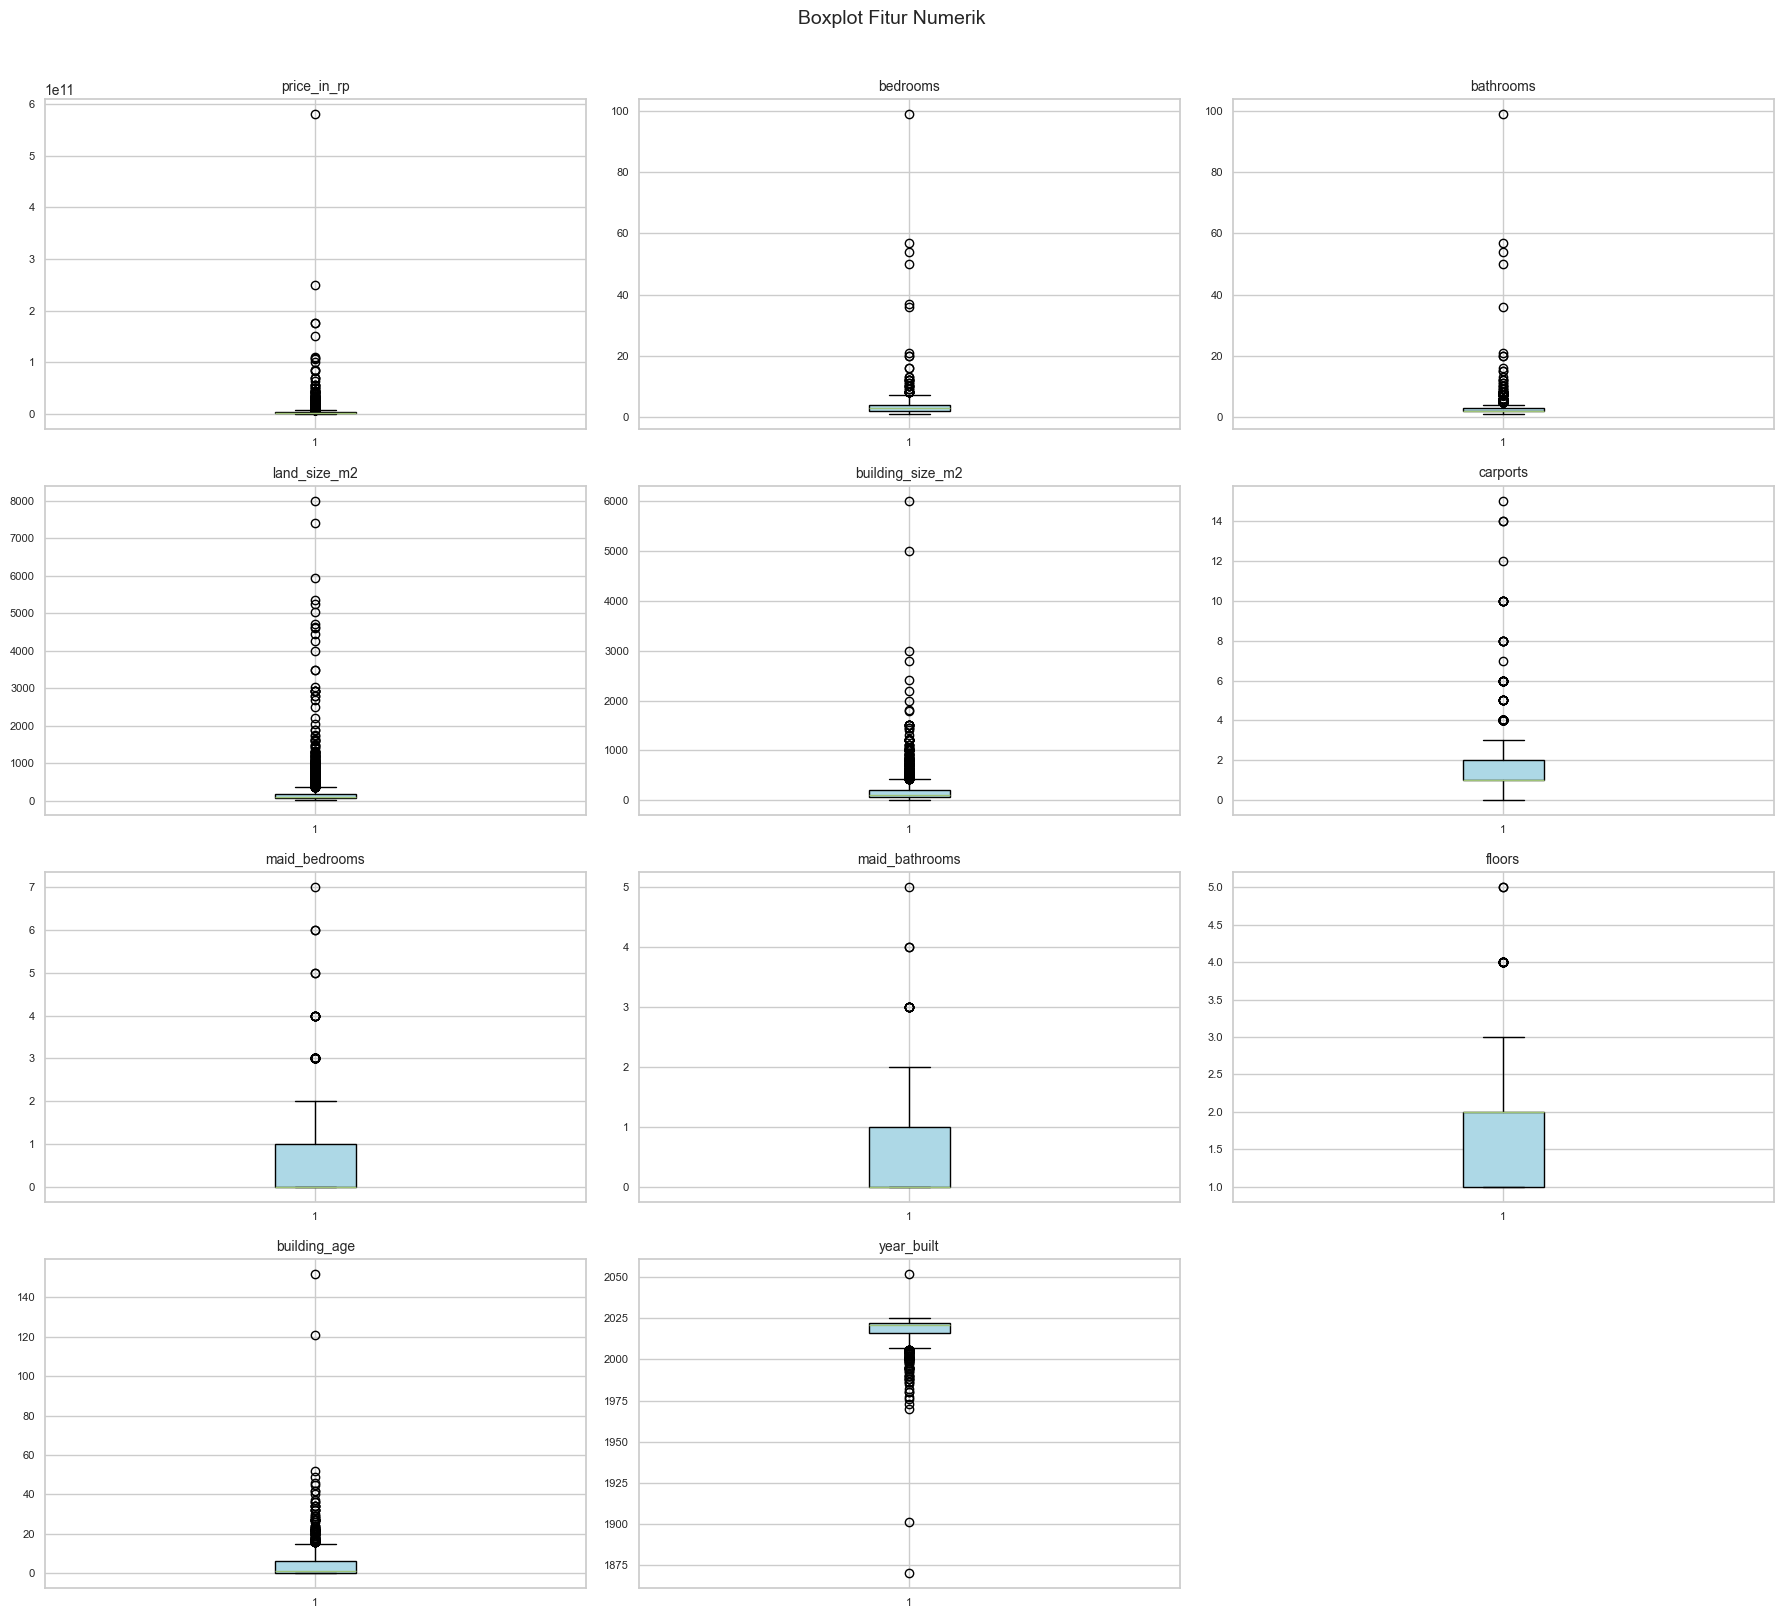

In [6]:
# Visualisasi boxplot untuk deteksi outlier pada fitur numerik
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten()
 
for i, col in enumerate(num_cols_hist):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Boxplot Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# DATA PREPROCESSING
# Mengecek dataset menggunakan isnull().sum()
print(df.isnull().sum())

# Mengecek dataset menggunakan duplicated().sum()
print(df.duplicated().sum())

# Menangani data yang hilang
df = df.dropna()
print(df.shape)

# Menghapus data duplikat
df = df.drop_duplicates()
print(df.shape)

url                        0
price_in_rp                0
title                      0
address                    0
district                   0
city                       0
lat                        0
long                       0
facilities                 0
property_type              1
ads_id                     4
bedrooms                  34
bathrooms                 29
land_size_m2               2
building_size_m2           2
carports                   0
certificate              141
electricity                0
maid_bedrooms              0
maid_bathrooms             0
floors                     6
building_age            1445
year_built              1445
property_condition       246
building_orientation    1647
garages                    0
furnishing               387
dtype: int64
0
(1280, 27)
(1280, 27)


In [8]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address
cols_to_drop = [c for c in df.columns if c in
                ['url', 'ads_id', 'address', 'lat', 'long']]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
 
print(df.columns.tolist())
print(df.shape)

['price_in_rp', 'title', 'district', 'city', 'facilities', 'property_type', 'bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'carports', 'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms', 'floors', 'building_age', 'year_built', 'property_condition', 'building_orientation', 'garages', 'furnishing']
(1280, 22)


In [9]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
encoders = {}
 
for col in cat_cols:
    le            = LabelEncoder()
    df[col]       = le.fit_transform(df[col].astype(str))
    encoders[col] = le
 
print(df.head())

     price_in_rp  title  district  city  facilities  property_type  bedrooms  \
3   3.300000e+09    699       246     0         190              0       3.0   
4   4.500000e+09    657       246     0         259              0       4.0   
5   2.700000e+09    893       246     0         610              0       3.0   
13  2.350000e+09    234       246     0         259              0       3.0   
15  2.700000e+09    491       246     0        1017              0       3.0   

    bathrooms  land_size_m2  building_size_m2  ...  electricity  \
3         3.0         180.0             174.0  ...           14   
4         3.0         328.0             196.0  ...           14   
5         3.0         136.0             200.0  ...           14   
13        3.0         144.0             149.0  ...            9   
15        3.0         193.0             136.0  ...           14   

    maid_bedrooms  maid_bathrooms  floors  building_age  year_built  \
3             1.0             1.0     2.0    

In [10]:
# Last checking menggunakan columns.tolist() untuk checking seluruh fitur yang ada
print(df.columns.tolist())
print(df.shape)
print(df.dtypes)

['price_in_rp', 'title', 'district', 'city', 'facilities', 'property_type', 'bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'carports', 'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms', 'floors', 'building_age', 'year_built', 'property_condition', 'building_orientation', 'garages', 'furnishing']
(1280, 22)
price_in_rp             float64
title                     int32
district                  int32
city                      int32
facilities                int32
property_type             int32
bedrooms                float64
bathrooms               float64
land_size_m2            float64
building_size_m2        float64
carports                float64
certificate               int32
electricity               int32
maid_bedrooms           float64
maid_bathrooms          float64
floors                  float64
building_age            float64
year_built              float64
property_condition        int32
building_orientation      int32
garages                 

In [11]:
# Melakukan Handling Outlier Data menggunakan metode drop
rows_before = df.shape[0]
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df    = df[(df[col] >= lower) & (df[col] <= upper)]
 
print(f"Baris sebelum: {rows_before}, setelah drop outlier: {df.shape[0]}")

Baris sebelum: 1280, setelah drop outlier: 729


In [12]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik
scaler              = StandardScaler()
df_scaled           = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
print(df_scaled[num_cols].describe().round(3))

       price_in_rp  bedrooms  bathrooms  land_size_m2  building_size_m2  \
count      729.000   729.000    729.000       729.000           729.000   
mean         0.000     0.000     -0.000         0.000            -0.000   
std          1.001     1.001      1.001         1.001             1.001   
min         -0.941    -2.307     -1.118        -1.929            -1.156   
25%         -0.591    -1.010     -1.118        -0.634            -0.752   
50%         -0.423     0.286     -0.053        -0.340            -0.348   
75%          0.121     0.286      1.013         0.395             0.423   
max          4.653     4.177      4.209         3.895             3.601   

       carports  maid_bedrooms  maid_bathrooms   floors  building_age  \
count   729.000        729.000         729.000  729.000       729.000   
mean     -0.000          0.000           0.000   -0.000        -0.000   
std       1.001          1.001           1.001    1.001         1.001   
min      -2.030         -0.488  

In [13]:
# Melakukan binning pada fitur price_in_rp dan building_size_m2
# encode hasil binning menggunakan LabelEncoder
bin_targets = [c for c in ['price_in_rp', 'building_size_m2'] if c in num_cols]
if not bin_targets:
    bin_targets = num_cols[:2]
 
for col in bin_targets:
    bin_col              = col + '_bin'
    df[bin_col]          = pd.cut(df[col], bins=4,
                                   labels=['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi'])
    le_bin               = LabelEncoder()
    df[bin_col + '_enc'] = le_bin.fit_transform(df[bin_col].astype(str))
    encoders[bin_col]    = le_bin
    print(f"\nDistribusi binning {col}:")
    print(df[bin_col].value_counts())
 
df_scaled           = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])


Distribusi binning price_in_rp:
price_in_rp_bin
Rendah           601
Sedang            79
Tinggi            34
Sangat Tinggi     15
Name: count, dtype: int64

Distribusi binning building_size_m2:
building_size_m2_bin
Rendah           480
Sedang           162
Tinggi            58
Sangat Tinggi     29
Name: count, dtype: int64


In [14]:
# menggunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
print(df_scaled.describe())

        price_in_rp        title    district        city   facilities  \
count  7.290000e+02   729.000000  729.000000  729.000000   729.000000   
mean   1.169618e-16   584.488340  116.163237    3.218107   505.310014   
std    1.000687e+00   335.974432   80.443701    3.096063   314.228354   
min   -9.409607e-01     1.000000    0.000000    0.000000     0.000000   
25%   -5.907309e-01   311.000000   51.000000    1.000000   199.000000   
50%   -4.225045e-01   577.000000  106.000000    2.000000   512.000000   
75%    1.213307e-01   841.000000  188.000000    6.000000   788.000000   
max    4.653291e+00  1215.000000  267.000000    8.000000  1034.000000   

       property_type      bedrooms     bathrooms  land_size_m2  \
count          729.0  7.290000e+02  7.290000e+02  7.290000e+02   
mean             0.0  1.559490e-16 -3.118980e-16  1.072150e-16   
std              0.0  1.000687e+00  1.000687e+00  1.000687e+00   
min              0.0 -2.307332e+00 -1.118034e+00 -1.928531e+00   
25%         

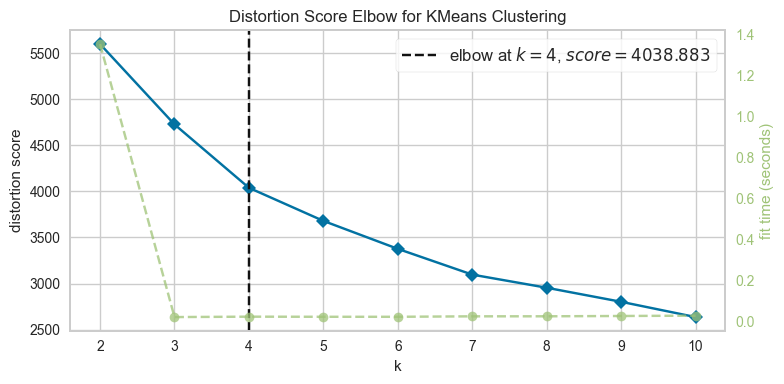

K Optimal: 4


In [15]:
# MODELING CLUSTERING
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
X_cluster = df_scaled[num_cols].values
 
try:
    fig, ax    = plt.subplots(figsize=(8, 4))
    visualizer = KElbowVisualizer(KMeans(random_state=42, n_init=10), k=(2, 11), ax=ax)
    visualizer.fit(X_cluster)
    visualizer.finalize()
    plt.tight_layout()
    plt.savefig('elbow_kelbow.png', dpi=150, bbox_inches='tight')
    plt.show()
    K_OPTIMAL = visualizer.elbow_value_ or 3
 
except Exception as e:
    print(f"KElbowVisualizer error: {e}")
    inertia = []
    K_range = range(2, 11)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_cluster)
        inertia.append(km.inertia_)
 
    plt.figure(figsize=(8, 4))
    plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Jumlah Cluster (K)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.xticks(K_range)
    plt.tight_layout()
    plt.savefig('elbow_kelbow.png', dpi=150)
    plt.show()
 
    diffs     = np.diff(inertia)
    diffs2    = np.diff(diffs)
    K_OPTIMAL = int(K_range[np.argmax(diffs2) + 2])
 
print(f"K Optimal: {K_OPTIMAL}")

In [16]:
# Menggunakan algoritma K-Means Clustering
kmeans         = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
 
df['Target']        = cluster_labels
df_scaled['Target'] = cluster_labels
 
print(pd.Series(cluster_labels).value_counts().sort_index())

0    241
1    142
2    250
3     96
Name: count, dtype: int64


In [17]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, 'model_clustering.h5')
print("Model disimpan: model_clustering.h5")

Model disimpan: model_clustering.h5


In [18]:
# Menghitung dan menampilkan nilai Silhouette Score
sil = silhouette_score(X_cluster, cluster_labels)
print(f"Silhouette Score: {sil:.4f}")

Silhouette Score: 0.2629


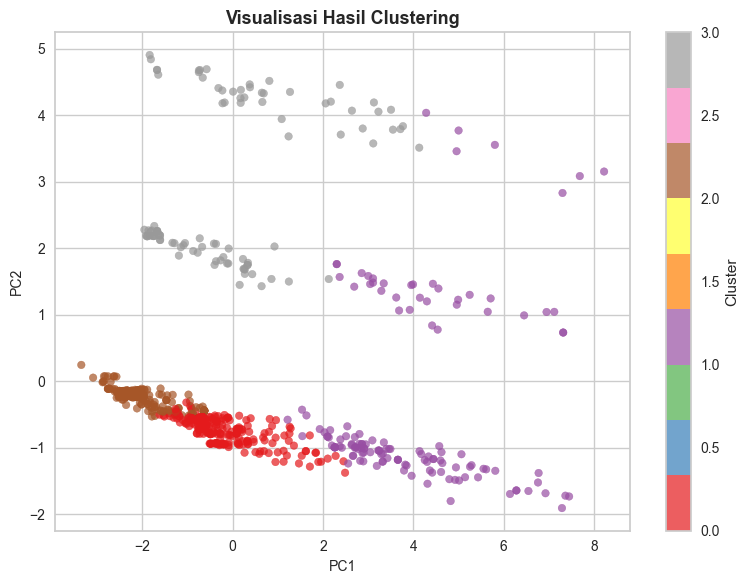

In [19]:
# Membuat visualisasi hasil clustering menggunakan PCA 2D
pca_vis = PCA(n_components=2, random_state=42)
X_vis   = pca_vis.fit_transform(X_cluster)
 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1],
                      c=cluster_labels, cmap='Set1', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)
plt.title('Visualisasi Hasil Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_result_pca.png', dpi=150)
plt.show()

In [20]:
# Membangun model menggunakan PCA
pca        = PCA(n_components=0.95, random_state=42)
X_pca      = pca.fit_transform(X_cluster)
print(f"Jumlah komponen PCA (95% variance): {pca.n_components_}")
 
kmeans_pca = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca    = silhouette_score(X_pca, labels_pca)
print(f"Silhouette Score PCA: {sil_pca:.4f}")

Jumlah komponen PCA (95% variance): 8
Silhouette Score PCA: 0.2812


In [21]:
# Menyimpan model PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")
print("Model disimpan: PCA_model_clustering.h5")

Model disimpan: PCA_model_clustering.h5


In [22]:
# INTERPRETASI HASIL CLUSTERING
# Menampilkan analisis deskriptif mean, min, dan max untuk fitur numerik per cluster
print(df.groupby('Target')[num_cols].agg(['mean', 'min', 'max']))

         price_in_rp                             bedrooms           bathrooms  \
                mean          min           max      mean  min  max      mean   
Target                                                                          
0       1.063896e+09  145000000.0  3.830000e+09  3.029046  2.0  5.0  2.290456   
1       3.512106e+09  999000000.0  7.800000e+09  3.626761  2.0  6.0  3.218310   
2       5.806880e+08  100000000.0  6.640000e+09  2.132000  1.0  3.0  1.208000   
3       1.121656e+09   85000000.0  4.100000e+09  2.583333  1.0  5.0  1.906250   

                 land_size_m2  ... floors building_age             year_built  \
        min  max         mean  ...    max         mean  min  max         mean   
Target                         ...                                              
0       1.0  4.0    74.933610  ...    3.0     0.000000  0.0  0.0  2022.000000   
1       2.0  6.0   127.950704  ...    3.0     0.323944  0.0  2.0  2021.676056   
2       1.0  2.0    66.2880

In [23]:
# Menjelaskan karakteristik tiap cluster berdasarkan hasil proses agregasi
for c in range(K_OPTIMAL):
    sub = df[df['Target'] == c]
    print(f"\nCluster {c} (n={len(sub)})")
    print(sub[num_cols].agg(['mean', 'min', 'max']).T)


Cluster 0 (n=241)
                          mean          min           max
price_in_rp       1.063896e+09  145000000.0  3.830000e+09
bedrooms          3.029046e+00          2.0  5.000000e+00
bathrooms         2.290456e+00          1.0  4.000000e+00
land_size_m2      7.493361e+01         33.0  1.750000e+02
building_size_m2  7.864315e+01         40.0  1.600000e+02
carports          1.315353e+00          0.0  2.000000e+00
maid_bedrooms     4.564315e-02          0.0  1.000000e+00
maid_bathrooms    1.659751e-02          0.0  1.000000e+00
floors            1.987552e+00          1.0  3.000000e+00
building_age      0.000000e+00          0.0  0.000000e+00
year_built        2.022000e+03       2022.0  2.022000e+03
garages           6.846473e-01          0.0  2.000000e+00

Cluster 1 (n=142)
                          mean          min           max
price_in_rp       3.512106e+09  999000000.0  7.800000e+09
bedrooms          3.626761e+00          2.0  6.000000e+00
bathrooms         3.218310e+00    

In [24]:
# Memastikan nama kolom clustering sudah diubah menjadi Target
print(df.columns.tolist())

['price_in_rp', 'title', 'district', 'city', 'facilities', 'property_type', 'bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'carports', 'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms', 'floors', 'building_age', 'year_built', 'property_condition', 'building_orientation', 'garages', 'furnishing', 'price_in_rp_bin', 'price_in_rp_bin_enc', 'building_size_m2_bin', 'building_size_m2_bin_enc', 'Target']


In [25]:
# Menyimpan Data training beserta hasil clustering
df_scaled.to_csv("data_clustering.csv", index=False)
print("Disimpan: data_clustering.csv")

Disimpan: data_clustering.csv


In [26]:
# Mengembalikan data numerik ke rentang normal menggunakan inverse_transform()
df_inverse           = df_scaled.copy()
df_inverse[num_cols] = scaler.inverse_transform(df_scaled[num_cols])
 
# Mengembalikan data kategorikal ke nilai aslinya
for col in cat_cols:
    if col in encoders and col in df_inverse.columns:
        df_inverse[col] = encoders[col].inverse_transform(
            df_inverse[col].astype(int))
 
print(df_inverse.head())

     price_in_rp                                              title  \
21  1.250000e+08          Rumah mewah Sertategis di Jatiasih Bekasi   
22  1.980000e+09               Rumah Siap Huni di Summarecon Bekasi   
28  4.800000e+08        Rumah minimalis termurah di jatiasih bekasi   
30  3.000000e+08  Rumah murah di Bekasi, gabus tambun utara Deka...   
41  1.200000e+09  Rumah 2lantai di bekasi kota deket tol bekasi ...   

             district     city  \
21  Summarecon Bekasi   Bekasi   
22  Summarecon Bekasi   Bekasi   
28  Summarecon Bekasi   Bekasi   
30             Bekasi   Bekasi   
41             Bekasi   Bekasi   

                                           facilities property_type  bedrooms  \
21                                              Taman         rumah       3.0   
22  Tempat Jemuran,  Jogging Track,  Track Lari,  ...         rumah       2.0   
28                                    Keamanan, Taman         rumah       2.0   
30   Taman, Ac, AC,  Masjid, Jalur Telepon, 

In [27]:
# Analisis deskriptif fitur numerik (mean, min, max) per cluster setelah inverse
print(df_inverse.groupby('Target')[num_cols].agg(['mean', 'min', 'max']))

         price_in_rp                             bedrooms           bathrooms  \
                mean          min           max      mean  min  max      mean   
Target                                                                          
0       1.063896e+09  145000000.0  3.830000e+09  3.029046  2.0  5.0  2.290456   
1       3.512106e+09  999000000.0  7.800000e+09  3.626761  2.0  6.0  3.218310   
2       5.806880e+08  100000000.0  6.640000e+09  2.132000  1.0  3.0  1.208000   
3       1.121656e+09   85000000.0  4.100000e+09  2.583333  1.0  5.0  1.906250   

                 land_size_m2  ... floors building_age             year_built  \
        min  max         mean  ...    max         mean  min  max         mean   
Target                         ...                                              
0       1.0  4.0    74.933610  ...    3.0     0.000000  0.0  0.0  2022.000000   
1       2.0  6.0   127.950704  ...    3.0     0.323944  0.0  2.0  2021.676056   
2       1.0  2.0    66.2880

In [28]:
# Analisis deskriptif fitur kategorikal (mode) per cluster setelah inverse
for col in cat_cols:
    if col in df_inverse.columns:
        print(f"\n{col}:")
        print(df_inverse.groupby('Target')[col].agg(
            lambda x: x.mode()[0] if len(x) > 0 else np.nan))


title:
Target
0    Rumah Mewah 2 Lantai Model Scandinavian Modern...
1        Dijual Brand New Rumah 8x12.5 PIK2, TERMURAH!
2    RUMAH STRATEGIS SIAP HUNI DI CIKEAS SERTIFIKAT...
3                  Hunian cantik dekat sts Bojong gede
Name: title, dtype: object

district:
Target
0       Sawangan
1    Alam Sutera
2         Cikeas
3       Cibinong
Name: district, dtype: object

city:
Target
0     Tangerang
1     Tangerang
2         Bogor
3     Tangerang
Name: city, dtype: object

facilities:
Target
0    Kulkas, Masjid,  Taman, Lapangan Bola, Tempat ...
1     Ac,  Taman, Jogging Track, Keamanan,  CCTV,  ...
2                                                Taman
3           Ac,  Taman,  CCTV, Jalur Telepon, Keamanan
Name: facilities, dtype: object

property_type:
Target
0    rumah
1    rumah
2    rumah
3    rumah
Name: property_type, dtype: object

certificate:
Target
0    shm - sertifikat hak milik
1    shm - sertifikat hak milik
2    shm - sertifikat hak milik
3    shm - sertifikat hak m

In [29]:
# Menjelaskan karakteristik tiap cluster berdasarkan data inverse
for c in range(K_OPTIMAL):
    sub = df_inverse[df_inverse['Target'] == c]
    print(f"\nCluster {c} (n={len(sub)})")
    for col in num_cols:
        print(f"  {col}: mean={sub[col].mean():.2f}, min={sub[col].min():.2f}, max={sub[col].max():.2f}")
    for col in cat_cols:
        if col in sub.columns:
            mode_val = sub[col].mode()[0] if len(sub) > 0 else '-'
            print(f"  {col} (mode): {mode_val}")


Cluster 0 (n=241)
  price_in_rp: mean=1063896265.56, min=145000000.00, max=3830000000.00
  bedrooms: mean=3.03, min=2.00, max=5.00
  bathrooms: mean=2.29, min=1.00, max=4.00
  land_size_m2: mean=74.93, min=33.00, max=175.00
  building_size_m2: mean=78.64, min=40.00, max=160.00
  carports: mean=1.32, min=0.00, max=2.00
  maid_bedrooms: mean=0.05, min=0.00, max=1.00
  maid_bathrooms: mean=0.02, min=0.00, max=1.00
  floors: mean=1.99, min=1.00, max=3.00
  building_age: mean=0.00, min=0.00, max=0.00
  year_built: mean=2022.00, min=2022.00, max=2022.00
  garages: mean=0.68, min=0.00, max=2.00
  title (mode): Rumah Mewah 2 Lantai Model Scandinavian Modern Cinere Krukut. Lokasi 50 Meter Dari Jalan Raya Krukut
  district (mode): Sawangan
  city (mode):  Tangerang
  facilities (mode): Kulkas, Masjid,  Taman, Lapangan Bola, Tempat Jemuran, Jalur Telepon, Lapangan Bulu Tangkis,  Track Lari, Keamanan 24 jam, Wastafel,  Akses Parkir,  One Gate System,  AC,  Tempat Laundry,  Playground
  property_t

In [30]:
# Memeriksa kembali data yang telah di-inverse
print(df_inverse.head())
print(df_inverse.shape)
print(df_inverse.dtypes)
print(df_inverse.isnull().sum())

     price_in_rp                                              title  \
21  1.250000e+08          Rumah mewah Sertategis di Jatiasih Bekasi   
22  1.980000e+09               Rumah Siap Huni di Summarecon Bekasi   
28  4.800000e+08        Rumah minimalis termurah di jatiasih bekasi   
30  3.000000e+08  Rumah murah di Bekasi, gabus tambun utara Deka...   
41  1.200000e+09  Rumah 2lantai di bekasi kota deket tol bekasi ...   

             district     city  \
21  Summarecon Bekasi   Bekasi   
22  Summarecon Bekasi   Bekasi   
28  Summarecon Bekasi   Bekasi   
30             Bekasi   Bekasi   
41             Bekasi   Bekasi   

                                           facilities property_type  bedrooms  \
21                                              Taman         rumah       3.0   
22  Tempat Jemuran,  Jogging Track,  Track Lari,  ...         rumah       2.0   
28                                    Keamanan, Taman         rumah       2.0   
30   Taman, Ac, AC,  Masjid, Jalur Telepon, 

In [31]:
# Mengintegrasikan kembali data inverse dengan kolom Target
df_inverse['Target'] = df_scaled['Target'].values

In [32]:
# Menyimpan data hasil inverse dan kolom Target ke dalam file data_clustering_inverse.csv
df_inverse.to_csv("data_clustering_inverse.csv", index=False)
print("Disimpan: data_clustering_inverse.csv")
print(df_inverse.head())

Disimpan: data_clustering_inverse.csv
     price_in_rp                                              title  \
21  1.250000e+08          Rumah mewah Sertategis di Jatiasih Bekasi   
22  1.980000e+09               Rumah Siap Huni di Summarecon Bekasi   
28  4.800000e+08        Rumah minimalis termurah di jatiasih bekasi   
30  3.000000e+08  Rumah murah di Bekasi, gabus tambun utara Deka...   
41  1.200000e+09  Rumah 2lantai di bekasi kota deket tol bekasi ...   

             district     city  \
21  Summarecon Bekasi   Bekasi   
22  Summarecon Bekasi   Bekasi   
28  Summarecon Bekasi   Bekasi   
30             Bekasi   Bekasi   
41             Bekasi   Bekasi   

                                           facilities property_type  bedrooms  \
21                                              Taman         rumah       3.0   
22  Tempat Jemuran,  Jogging Track,  Track Lari,  ...         rumah       2.0   
28                                    Keamanan, Taman         rumah       2.0   
30   T